Processing Delta Band...


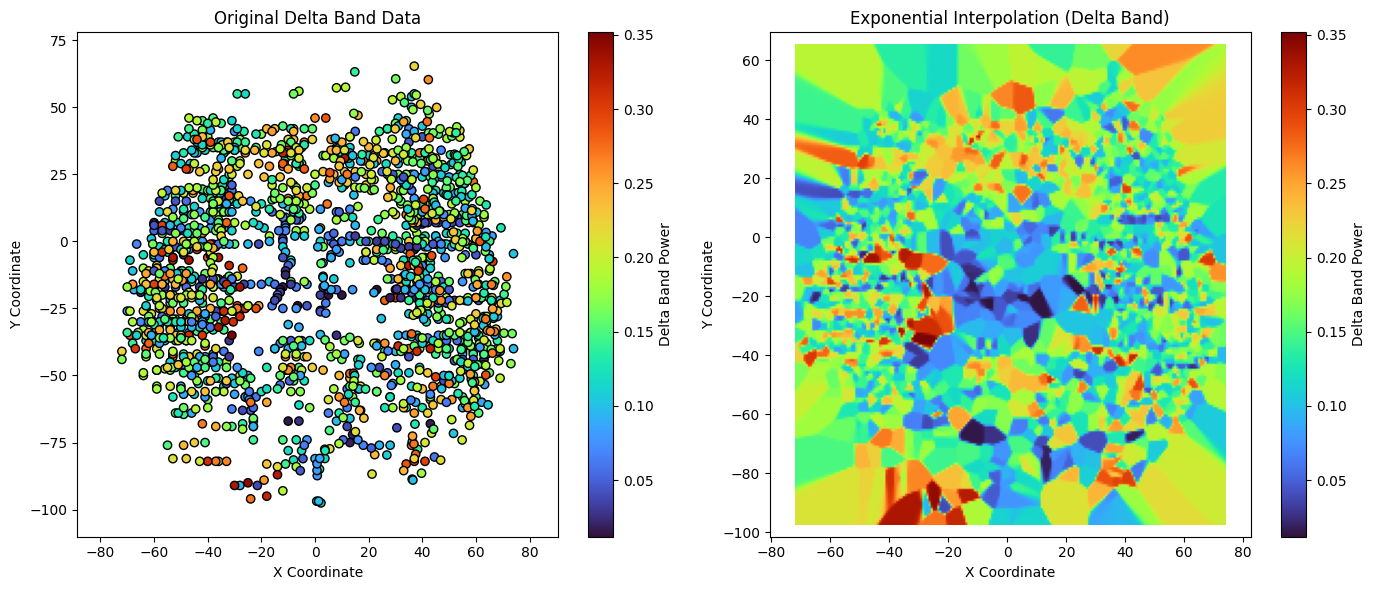

Processing Theta Band...


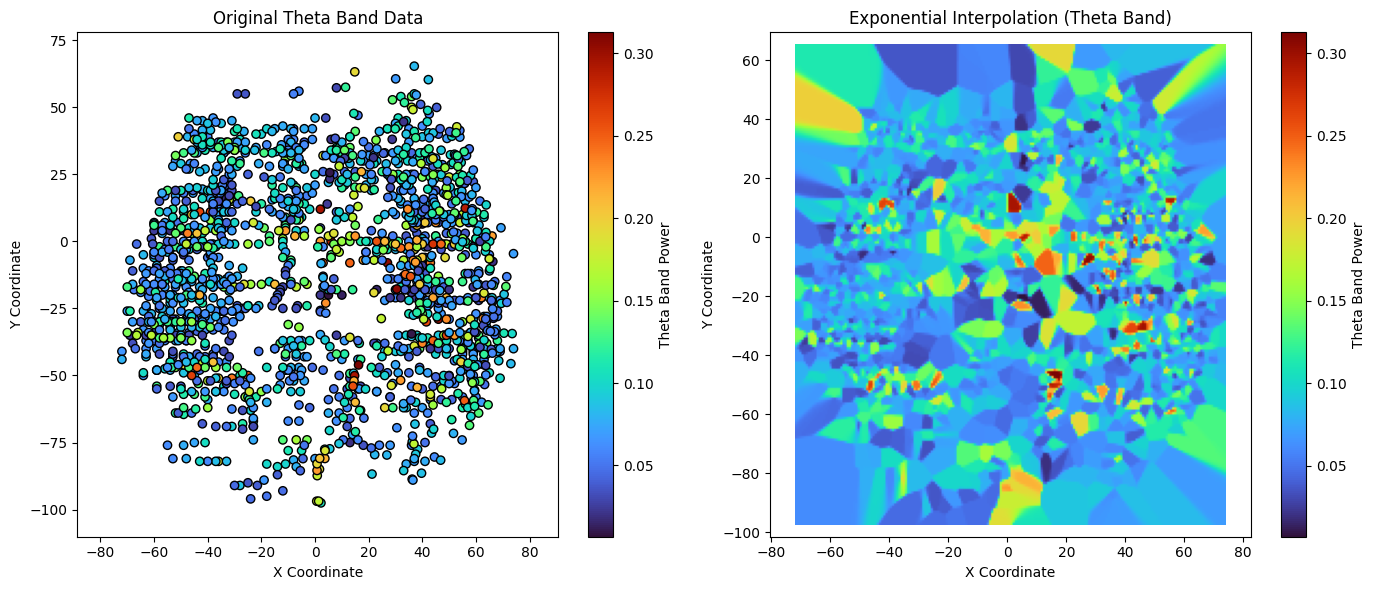

Processing Alpha Band...


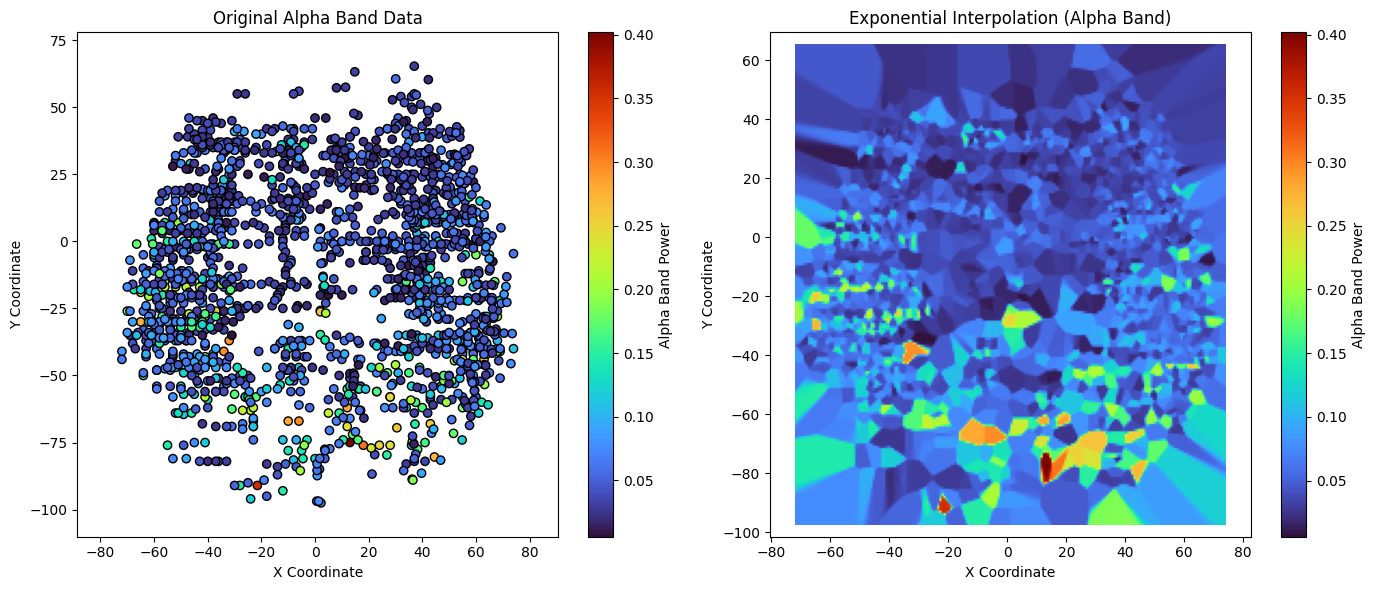

Processing Beta Band...


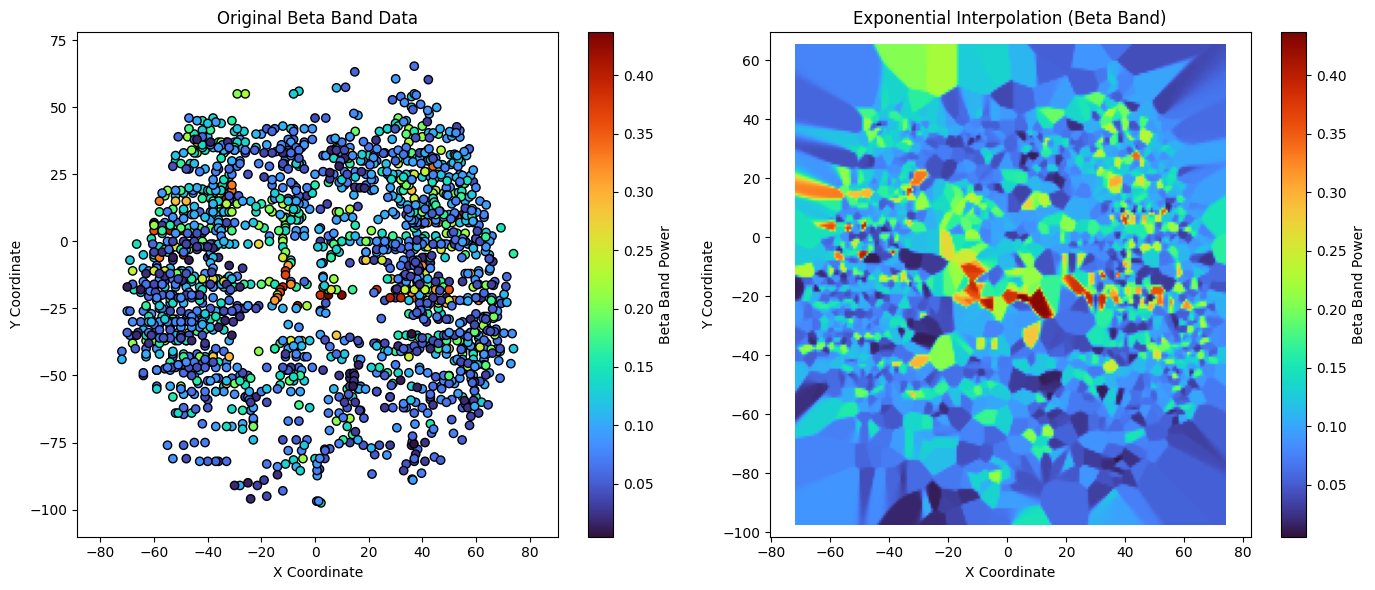

Processing Gamma Band...


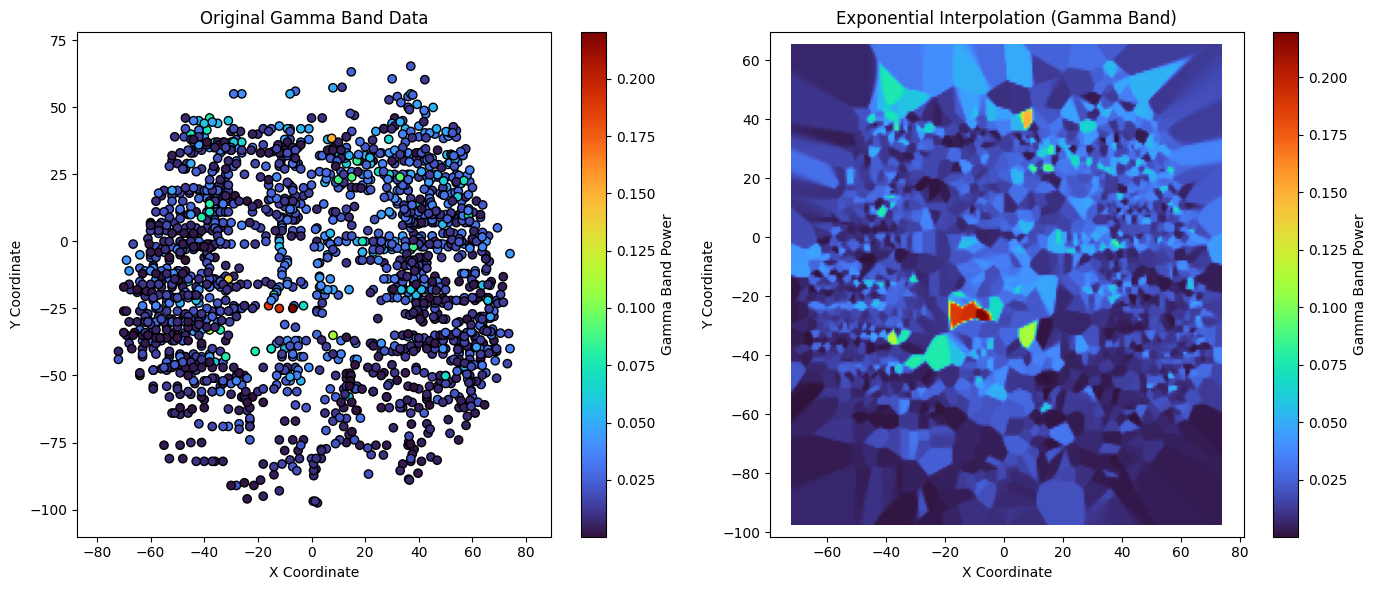


Interpolation Evaluation Metrics:
            MSE       MAE      RMSE        R²
Delta  0.000217  0.004099  0.014721  0.954922
Theta  0.000098  0.002786  0.009916  0.959051
Alpha  0.000127  0.002437  0.011269  0.946530
Beta   0.000142  0.003357  0.011913  0.972323
Gamma  0.000014  0.000954  0.003794  0.957176


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import pandas as pd

# Load the data
coords = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# Extract x, y coordinates
x, y = coords[:, 0], coords[:, 1]

# Define a grid for interpolation
resolution = 200
grid_x, grid_y = np.meshgrid(
    np.linspace(min(x), max(x), resolution),
    np.linspace(min(y), max(y), resolution)
)

# Exponential interpolation function
def exponential_interpolation(x, y, values, grid_x, grid_y, alpha=5.0):
    grid_values = np.zeros_like(grid_x) #initialization
    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            gx, gy = grid_x[i, j], grid_y[i, j] #Interpolated grid point
            distances = np.sqrt((x - gx) ** 2 + (y - gy) ** 2) #Calculate Euclidean distance
            weights = np.exp(-alpha * distances)
            grid_values[i, j] = np.sum(weights * values) / np.sum(weights) # predicted points data
    return grid_values

# Prepare a dictionary to store evaluation metrics
evaluation_metrics = {}

# Iterate over each frequency band and perform exponential interpolation
alpha = 5.0  # Exponential decay factor
for band, values in band_powers.items(): #band_power is a python dict
    print(f'Processing {band} Band...')

    # Perform Exponential Interpolation
    grid_values = exponential_interpolation(x, y, values, grid_x, grid_y, alpha) # calling the function which can return the predicted point data

    # Evaluate interpolation accuracy by comparing interpolated values at original points
    interp_values_at_samples = exponential_interpolation(x, y, values, x.reshape(-1, 1), y.reshape(-1, 1), alpha)

    mse = mean_squared_error(values, interp_values_at_samples)
    mae = mean_absolute_error(values, interp_values_at_samples)
    rmse = sqrt(mse)
    r2 = r2_score(values, interp_values_at_samples)

    evaluation_metrics[band] = {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    # Plot original vs interpolated data
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter plot of original data
    sc = axes[0].scatter(x, y, c=values, cmap='turbo', edgecolors='k')
    axes[0].set_title(f'Original {band} Band Data')
    axes[0].set_xlabel('X Coordinate')
    axes[0].set_ylabel('Y Coordinate')
    axes[0].axis('equal')
    fig.colorbar(sc, ax=axes[0], label=f'{band} Band Power')

    # Heatmap of interpolated data
    i = axes[1].imshow(grid_values, extent=(min(x), max(x), min(y), max(y)), origin='lower', cmap='turbo')
    axes[1].set_title(f'Exponential Interpolation ({band} Band)')
    axes[1].set_xlabel('X Coordinate')
    axes[1].set_ylabel('Y Coordinate')
    axes[1].axis('equal')
    fig.colorbar(i, ax=axes[1], label=f'{band} Band Power')

    plt.tight_layout()
    plt.show()

# Convert evaluation metrics into a DataFrame and display
df_metrics = pd.DataFrame(evaluation_metrics).T
print("\nInterpolation Evaluation Metrics:")
print(df_metrics)


In [17]:
print(grid_x.shape[1])  # 输出 <class 'numpy.ndarray'>
#print(grid_x)
print(x.reshape(-1, 1))

200
[[-56.        ]
 [-60.        ]
 [-63.        ]
 ...
 [ 52.53571429]
 [  1.03571429]
 [  1.5       ]]
